# 🏢 **Descripción de la empresa**
La empresa opera en el **sector retail**, comercializando productos de consumo a través de **ventas principalmente B2C y pequeños mayoristas**, con una fuerte presencia en el mercado del Reino Unido y alcance internacional. Su modelo de negocio se basa en la venta por pedido, con un alto volumen de transacciones y una amplia variedad de productos.

# 📊 **Descripción de los datos**
El dataset utilizado contiene registros transaccionales reales de ventas, donde cada fila representa una operación comercial.
Entre las principales variables se incluyen:


*   Identificador de la factura

*   Elemento de lista
*   Elemento de lista



*   Código y descripción del producto
*   Cantidad vendida


*   Precio unitario


*  Fecha de la transacción
*   Identificador del cliente


*   País de origen del cliente

Estos datos permiten analizar el comportamiento de compra, el desempeño de los productos y la evolución de las ventas en el tiempo.

# 🎯 **Objetivo del análisis**
El objetivo de este análisis es **evaluar el desempeño comercial de la empresa** a partir de sus transacciones históricas, con el fin de:


*   Identificar tendencias de ventas y patrones temporales
*   Detectar los productos y clientes más relevantes para el negocio


*   Analizar la distribución de ingresos por país
*   Calcular indicadores clave de desempeño (KPIs)


*   Generar insights accionables que ayuden a mejorar la toma de decisiones comerciales y estratégicas

Este estudio busca **transformar los datos transaccionales en información útil para la gestión del negocio**, priorizando un enfoque analítico y orientado a resultados.















In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargar el dataset
# se usa (encoding='latin1') porque este dataset suele contener caracteres especiales en las descripciones de productos.

df = pd.read_csv('/content/online_retail.csv', encoding='latin1')

# Visualizar las primeras filas
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
# Renombrar columnas a español
df = df.rename(columns={
    'InvoiceNo': 'Número de factura',
    'StockCode': 'Código de producto',
    'Description': 'Descripción del producto',
    'Quantity': 'Cantidad',
    'InvoiceDate': 'Fecha de factura',
    'UnitPrice': 'Precio unitario',
    'CustomerID': 'ID de cliente',
      'Country': 'País'})

#Verificamos nombres de columnas
df.columns

Index(['Número de factura', 'Código de producto', 'Descripción del producto',
       'Cantidad', 'Fecha de factura', 'Precio unitario', 'ID de cliente',
       'País'],
      dtype='object')

In [4]:
# Informacion general de la estrauctura
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Número de factura         541909 non-null  object 
 1   Código de producto        541909 non-null  object 
 2   Descripción del producto  540455 non-null  object 
 3   Cantidad                  541909 non-null  int64  
 4   Fecha de factura          541909 non-null  object 
 5   Precio unitario           541909 non-null  float64
 6   ID de cliente             406829 non-null  float64
 7   País                      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


**Este paso permite:**


*   Conocer la cantidad de registros y columnas
*   Identificar tipos de datos


*   Detectar valores nulos
*   Ver que columnas requieren limpieza





In [5]:
# Resumen estadistico
df.describe()

,Cantidad,Precio unitario,ID de cliente
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


**Aqui analizamos:**


*   Distribucion de cantidades y precios
*   Valores minimos y maximos


*   Posibles outliers (cantidades negativas, precios en cero, etc.)






In [6]:
# Dimensiones del dataset
df.shape

(541909, 8)

**Esto nos indica:**


*   Cuantas transacciones hay
*   Que tan grande es el dataset antes de limpiar

**En resumen:**

A partir de la exploración inicial se observa que el dataset contiene registros transaccionales detallados de ventas, incluyendo información de productos, clientes, fechas y valores monetarios.
También se identifican posibles desafíos de calidad de datos, como valores nulos en el identificador de cliente, cantidades negativas asociadas a devoluciones y la necesidad de convertir correctamente la columna de fechas.



# Limpieza y preparacion de datos
Garantizar que los datos representen ventas reales y válidas, eliminando registros que puedan distorsionar el análisis y preparando nuevas variables clave para el estudio del desempeño comercial.

In [7]:
# Revision de valores nulos
df.isnull().sum().sort_values(ascending=False)

,0
ID de cliente,135080
Descripción del producto,1454
Código de producto,0
Número de factura,0
Cantidad,0
Fecha de factura,0
Precio unitario,0
País,0


**Interpretacion esperada:**


*   CustomerID presenta una proporción relevante de valores nulos.
*   El resto de las variables tiene muy pocos nulos.



In [8]:
# 1) Eliminación de registros sin clientes
df = df.dropna(subset=['ID de cliente']).copy()

# 2) Aseguramos tipos
df['ID de cliente'] = df['ID de cliente'].astype(int, errors='ignore')

# 3) Identificación de devoluciones/cancelaciones (sin eliminarlas)
df['EsCancelada'] = df['Número de factura'].astype(str).str.startswith('C')

# 4) Separación de datasets: ventas válidas vs devoluciones
ventas = df[(df['Cantidad'] > 0) & (df['Precio unitario'] > 0)].copy()

devoluciones = df[(df['Cantidad'] < 0) | (df['Precio unitario'] <= 0) | (df['EsCancelada'])].copy()

# 5) Verificación rápida de calidad
print("Nulos en df (base):")
display(df.isnull().sum().sort_values())

print("\nRegistros totales (con cliente):", len(df))
print("Ventas válidas:", len(ventas))
print("Devoluciones / cancelaciones:", len(devoluciones))

Nulos en df (base):


,0
Número de factura,0
Código de producto,0
Descripción del producto,0
Cantidad,0
Fecha de factura,0
Precio unitario,0
ID de cliente,0
País,0
EsCancelada,0



Registros totales (con cliente): 406829
Ventas válidas: 397884
Devoluciones / cancelaciones: 8945




*   **En esta etapa se realizó una depuración controlada del dataset**, eliminando únicamente los registros sin identificación de cliente, ya que no aportan valor analítico para el estudio del comportamiento comercial. A diferencia de una limpieza tradicional, las devoluciones y cancelaciones no fueron descartadas, sino identificadas y separadas del conjunto de ventas válidas.
*   **Este enfoque** permite mantener la trazabilidad del dato y habilita un análisis más realista del desempeño del negocio, diferenciando entre ingresos generados y pérdidas asociadas a devoluciones. **Como resultado, se obtienen datasets consistentes y alineados con objetivos de negocio**, preparados para el cálculo de KPIs financieros y análisis comerciales más profundos.






In [9]:
# Calcular Ingresos en datasets derivados (ventas y devoluciones)
ventas['Ingresos'] = ventas['Cantidad'] * ventas['Precio unitario']
devoluciones['Ingresos'] = devoluciones['Cantidad'] * devoluciones['Precio unitario']


In [10]:
# Conversion de la fecha
df['Fecha de factura'] = pd.to_datetime(df['Fecha de factura'])

**Conversion de la variable FECHA**
esto nos permitira:

*   análisis temporal
*   agregaciones mensuales

*   detección de estacionalidad






In [11]:
# Creación de la variable clave: Ingresos (Revenue)
df['Ingresos'] = df['Cantidad'] * df['Precio unitario']



*   Variable más importante del proyecto.
*   Variable fundamental para KPIs

*   Base de todo el análisis financiero






In [12]:
# Verificamos limpieza de datos
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 10 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   Número de factura         406829 non-null  object        
 1   Código de producto        406829 non-null  object        
 2   Descripción del producto  406829 non-null  object        
 3   Cantidad                  406829 non-null  int64         
 4   Fecha de factura          406829 non-null  datetime64[ns]
 5   Precio unitario           406829 non-null  float64       
 6   ID de cliente             406829 non-null  int64         
 7   País                      406829 non-null  object        
 8   EsCancelada               406829 non-null  bool          
 9   Ingresos                  406829 non-null  float64       
dtypes: bool(1), datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 31.4+ MB


In [13]:
df.describe()

,Cantidad,Fecha de factura,Precio unitario,ID de cliente,Ingresos
count,406829.000000,406829,406829.000000,406829.000000,406829.000000
mean,12.061303,2011-07-10 16:30:57.879207424,3.460471,15287.690570,20.401854
min,-80995.000000,2010-12-01 08:26:00,0.000000,12346.000000,-168469.600000
25%,2.000000,2011-04-06 15:02:00,1.250000,13953.000000,4.200000
50%,5.000000,2011-07-31 11:48:00,1.950000,15152.000000,11.100000
75%,12.000000,2011-10-20 13:06:00,3.750000,16791.000000,19.500000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,168469.600000
std,248.693370,NaN,69.315162,1713.600303,427.591718


In [14]:
df.shape

(406829, 10)

**Conclusion:**

Durante la etapa de limpieza se identificaron y dividieron registros que no representaban ventas reales, como devoluciones (cantidades negativas), precios inválidos y transacciones sin identificador de cliente.
Además, se transformó la variable de fecha a un formato adecuado para análisis temporal y se creó la variable de ingresos, calculada como el producto entre la cantidad vendida y el precio unitario.
Este proceso permitió obtener un dataset depurado y confiable, preparado para realizar análisis exploratorios y calcular indicadores clave de desempeño.

# Análisis Exploratorio de los Datos

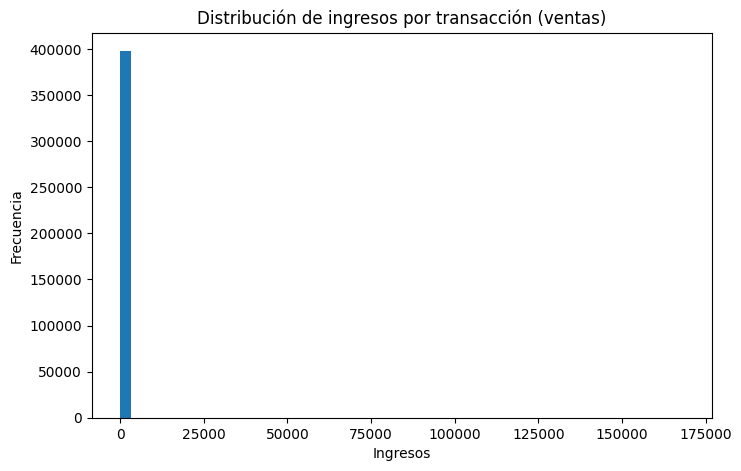

In [15]:
# Distribución de ingresos en ventas
plt.figure(figsize=(8,5))
plt.hist(ventas['Ingresos'], bins=50)
plt.title('Distribución de ingresos por transacción (ventas)')
plt.xlabel('Ingresos')
plt.ylabel('Frecuencia')
plt.show()

La distribución de los ingresos por transacción es **altamente asimétrica a la derecha**, lo que indica que la gran **mayoría de las ventas tiene importes bajos**, mientras que un número muy reducido de transacciones concentra valores extremadamente altos.

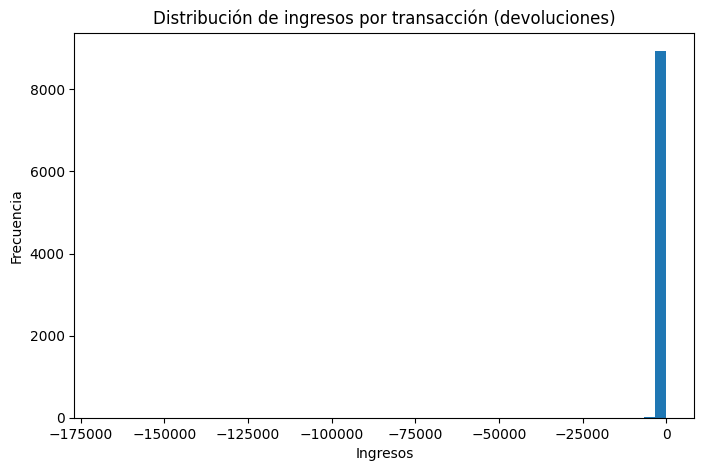

In [16]:
# Distribución de ingresos en devoluciones
plt.figure(figsize=(8,5))
plt.hist(devoluciones['Ingresos'], bins=50)
plt.title('Distribución de ingresos por transacción (devoluciones)')
plt.xlabel('Ingresos')
plt.ylabel('Frecuencia')
plt.show()



*   La distribución se concentra casi **exclusivamente en valores negativos**, como es esperable en operaciones de devolución o cancelación, con una **fuerte asimetría hacia la izquierda.**
*   La mayoría de las devoluciones presenta **impactos monetarios relativamente bajos**, mientras que existen casos puntuales de **devoluciones de alto valor que generan una cola larga negativa** y amplían la escala del gráfico



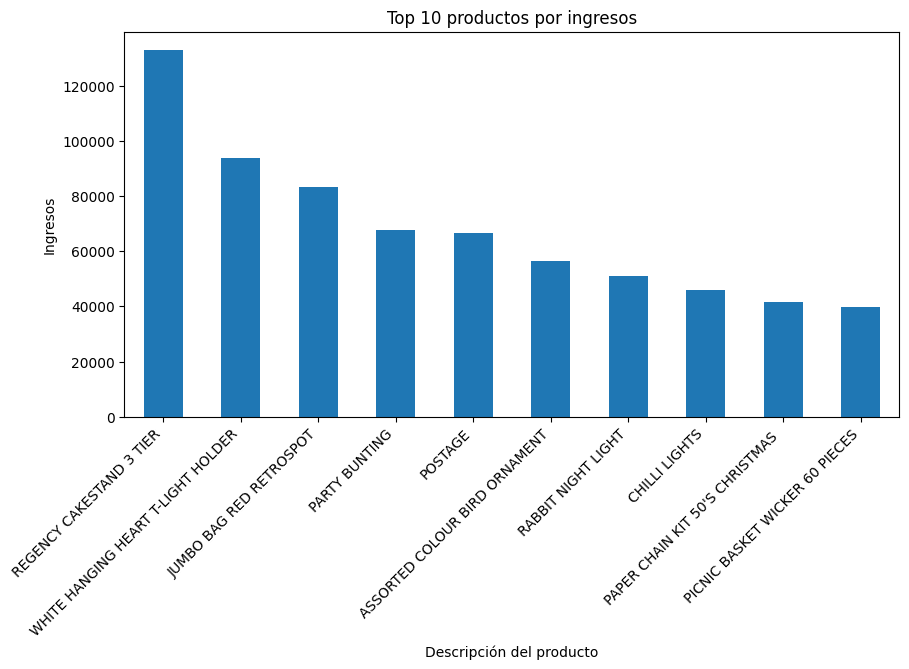

In [17]:
# Identificamos qué productos generan más dinero.
top_productos = (
    df.groupby('Descripción del producto')['Ingresos']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_productos

# Visualizacion
plt.figure(figsize=(10,5))
top_productos.plot(kind='bar')
plt.title('Top 10 productos por ingresos')
plt.ylabel('Ingresos')
plt.xticks(rotation=45, ha='right')
plt.show()



*   Alta concentración de ingresos en pocos productos
*   Riesgo de dependencia de un portfolio reducido



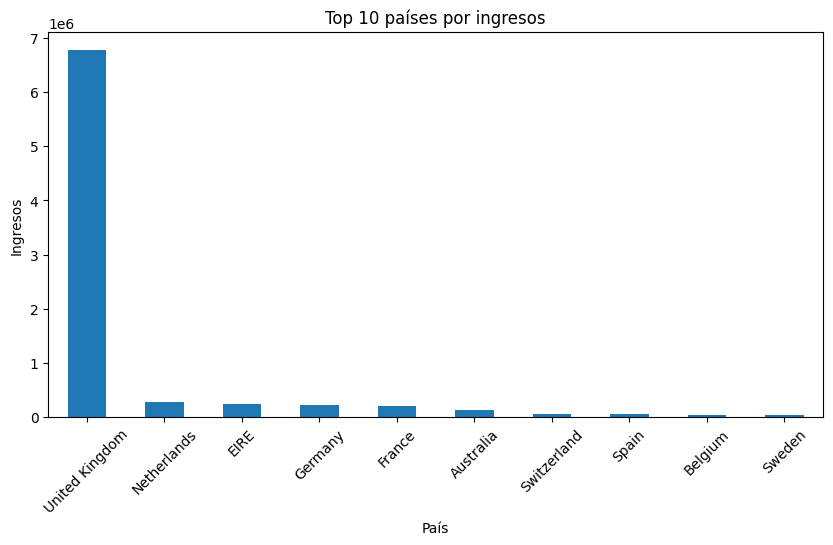

In [18]:
# Analizamos qué países aportan más ingresos.
ventas_pais = (
    df.groupby('País')['Ingresos']
      .sum()
      .sort_values(ascending=False)
)

ventas_pais.head(10)

# Visualizacion
plt.figure(figsize=(10,5))
ventas_pais.head(10).plot(kind='bar')
plt.title('Top 10 países por ingresos')
plt.ylabel('Ingresos')
plt.xticks(rotation=45)
plt.show()



*   Uno o dos países suelen dominar el mercado
*   Oportunidad de expansión o diversificación geográfica



In [19]:
# Análisis de clientes (concentración de ingresos)
top_clientes = (
    df.groupby('ID de cliente')['Ingresos']
      .sum()
      .sort_values(ascending=False)
)

top_clientes.head(10)




,Ingresos
ID de cliente,
14646,279489.02
18102,256438.49
17450,187482.17
14911,132572.62
12415,123725.45
14156,113384.14
17511,88125.38
16684,65892.08
13694,62653.10




*   Regla 80/20 (Pareto) suele cumplirse
*   Pocos clientes generan gran parte del revenue



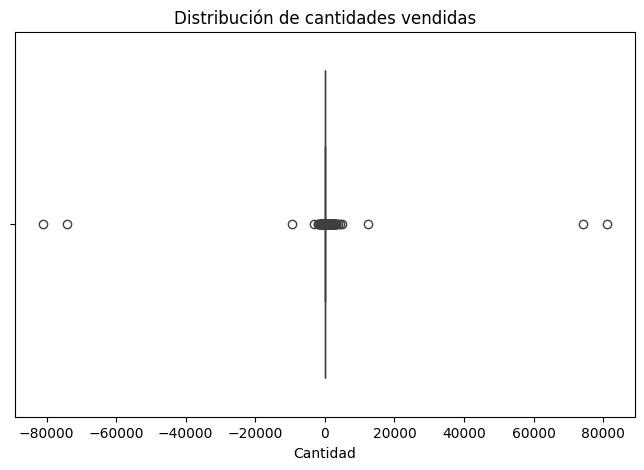

In [20]:
# Análisis de cantidades vendidas
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Cantidad'])
plt.title('Distribución de cantidades vendidas')
plt.show()



*   Outliers claros (compras grandes)
*   Mayoría de pedidos con pocas unidades

**Conclusion:**

El análisis exploratorio muestra que los ingresos por transacción presentan una distribución altamente sesgada, con un gran volumen de ventas de bajo valor y un número reducido de operaciones de alto impacto económico.
Se observan **valores atípicos extremos tanto positivos como negativos**. Los valores negativos están asociados a **devoluciones o cancelaciones**, mientras que los valores positivos elevados corresponden a **compras en grandes volúmenes**, posiblemente realizadas por clientes mayoristas o pedidos excepcionales.
La marcada presencia de outliers y la fuerte asimetría de la distribución indican que la variable no sigue un comportamiento normal, lo que puede distorsionar métricas agregadas como el promedio.
La mayoría de las ventas se realiza en pequeñas cantidades, mientras que un número reducido de transacciones —incluyendo devoluciones— genera valores extremos.


# Análisis temporal de las ventas

**Objetivo:**



*   tendencias
*   estacionalidad

*   meses de mayor y menor desempeño
*   patrones de crecimiento o caída





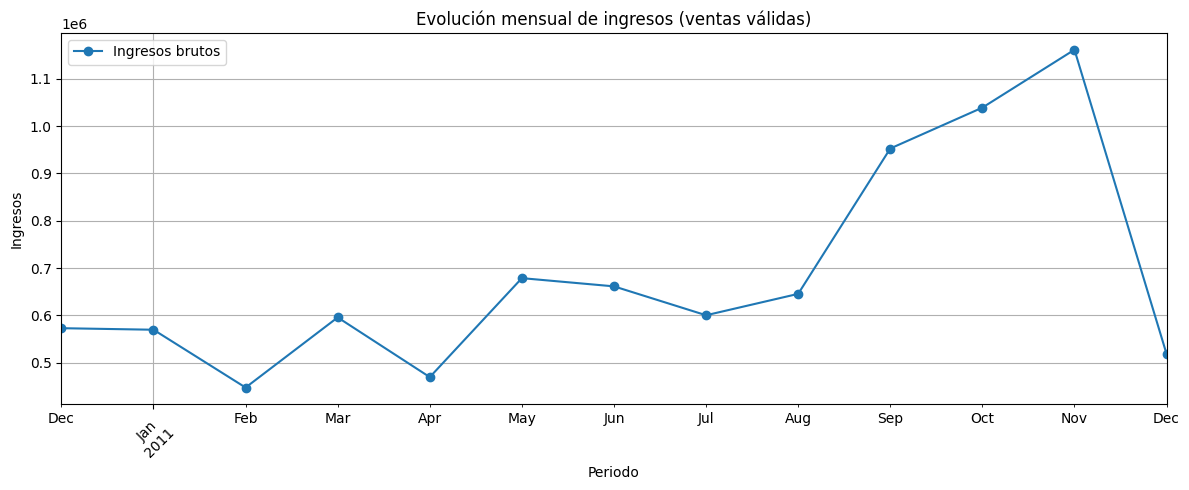

In [21]:
# Preparación temporal
ventas['Fecha de factura'] = pd.to_datetime(ventas['Fecha de factura'])
devoluciones['Fecha de factura'] = pd.to_datetime(devoluciones['Fecha de factura'])

ventas['Año-Mes'] = ventas['Fecha de factura'].dt.to_period('M')
devoluciones['Año-Mes'] = devoluciones['Fecha de factura'].dt.to_period('M')

# Ingresos brutos mensuales (solo ventas válidas)
ingresos_brutos_mensuales = (
    ventas.groupby('Año-Mes')['Ingresos']
    .sum()
    .sort_index()
)

plt.figure(figsize=(12,5))
ingresos_brutos_mensuales.plot(marker='o', label='Ingresos brutos')
plt.title('Evolución mensual de ingresos (ventas válidas)')
plt.xlabel('Periodo')
plt.ylabel('Ingresos')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



El gráfico muestra una **tendencia general creciente** de los ingresos a lo largo del tiempo, con fluctuaciones moderadas en los primeros meses y un **crecimiento acelerado a partir de septiembre**.
El comportamiento sugiere **estacionalidad marcada**, lo que es clave para planificación comercial, gestión de inventario y campañas de marketing focalizadas en los meses de mayor rendimiento.

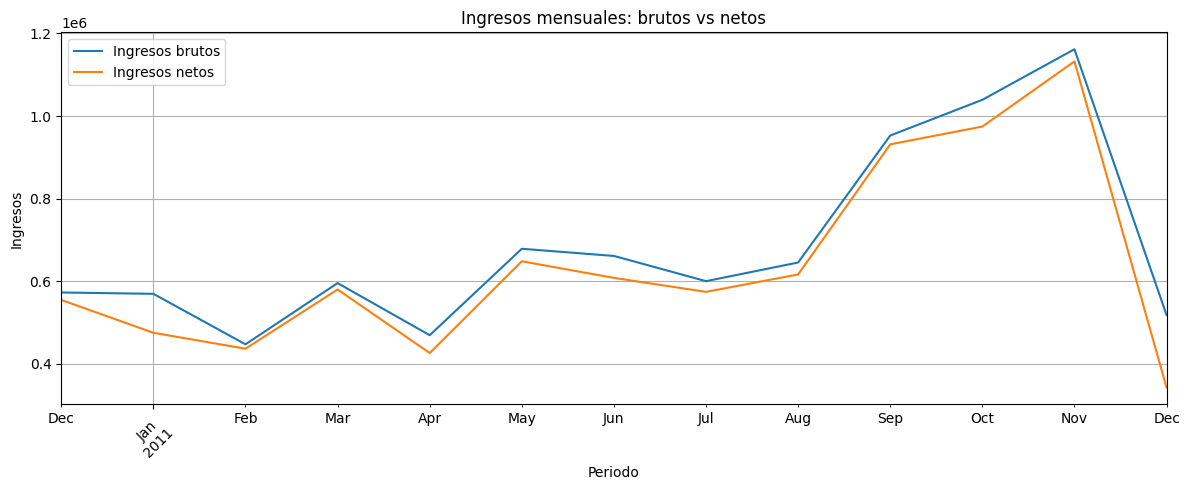

In [22]:
# Ingresos netos mensuales (ventas + devoluciones)
ingresos_netos_mensuales = ingresos_brutos_mensuales.add(
    devoluciones.groupby('Año-Mes')['Ingresos'].sum(),
    fill_value=0
)

plt.figure(figsize=(12,5))
ingresos_brutos_mensuales.plot(label='Ingresos brutos')
ingresos_netos_mensuales.plot(label='Ingresos netos')
plt.title('Ingresos mensuales: brutos vs netos')
plt.xlabel('Periodo')
plt.ylabel('Ingresos')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



*   El gráfico muestra una **evolución mensual positiva de los ingresos**, con una clara tendencia de **crecimiento desde mayo hasta noviembre**, donde se alcanza el pico máximo tanto en ingresos brutos como netos.
*   La **brecha constante entre ingresos brutos y netos** indica un impacto sostenido de devoluciones o cancelaciones, que se mantiene relativamente estable a lo largo del año, sin picos anómalos.


*   Se observa una **caída pronunciada en diciembre**, especialmente en los ingresos netos, lo que sugiere un **efecto estacional**, posibles ajustes de cierre de año, o un aumento de devoluciones en ese período.
*   Desde una perspectiva de negocio, el desempeño es **sólido en el segundo semestre**, **pero diciembre merece un análisis específico** para entender y mitigar la pérdida neta de ingresos.





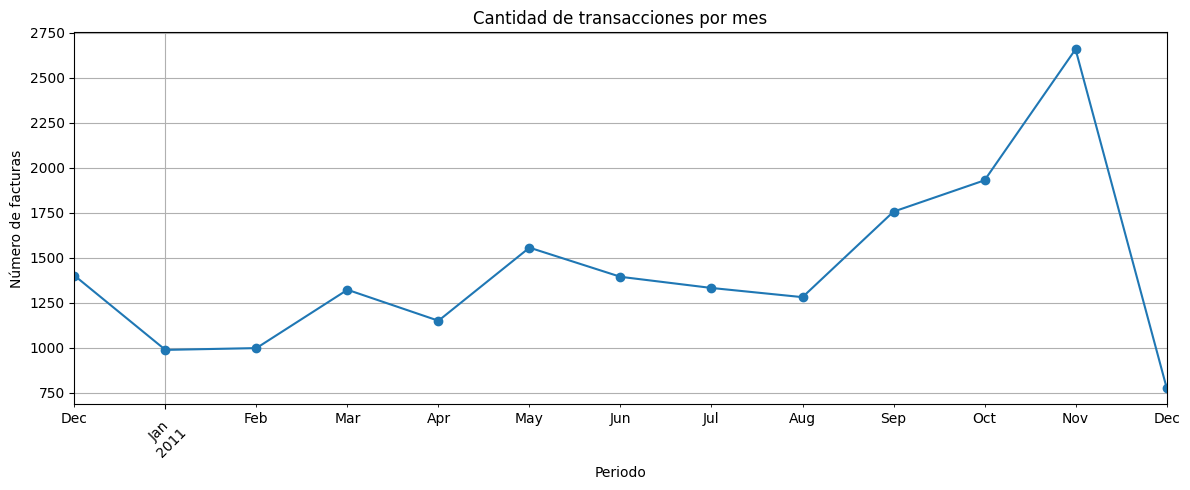

In [23]:
# Volumen de transacciones mensuales (ventas válidas)
transacciones_mensuales = (
    ventas.groupby('Año-Mes')['Número de factura']
    .nunique()
    .sort_index()
)

plt.figure(figsize=(12,5))
transacciones_mensuales.plot(marker='o')
plt.title('Cantidad de transacciones por mes')
plt.xlabel('Periodo')
plt.ylabel('Número de facturas')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()



*   Durante los primeros meses, el número de **transacciones se mantiene relativamente estable** con leves fluctuaciones.
*   A partir de **septiembre se observa un aumento** sostenido, alcanzando el **máximo en noviembre**, lo que indica un fuerte incremento en la actividad comercial.


*   **En diciembre se registra una caída abrupta**, probablemente asociada a datos incompletos del mes o a una reducción estacional de operaciones.





 **Conclusion Temporal:**

El análisis mensual realizado sobre ventas válidas muestra una tendencia general de crecimiento de los ingresos a lo largo del período analizado, con variaciones que sugieren la presencia de estacionalidad. La comparación entre ingresos brutos y netos evidencia que las devoluciones no impactan de manera uniforme en todos los meses, reduciendo de forma más significativa el resultado financiero en períodos puntuales.

Asimismo, el aumento del volumen de transacciones acompaña el crecimiento de los ingresos, lo que indica que el desempeño comercial se explica tanto por una mayor actividad como por variaciones en el valor de las ventas. Estos patrones temporales resultan clave para la planificación financiera, la gestión de inventarios y el diseño de campañas comerciales alineadas con los momentos de mayor demanda.


# KPIs de negocio
**Objetivo:**

Definir y calcular indicadores clave de desempeño (KPIs) que permitan evaluar el rendimiento comercial de la empresa y facilitar la toma de decisiones estratégicas.

In [24]:
# Ingresos brutos (ventas válidas)
ingresos_brutos = ventas['Ingresos'].sum()
ingresos_brutos

np.float64(8911407.904)

**Volumen total de ventas** generado durante el período analizado.
Es el KPI principal para evaluar el tamaño del negocio.

In [25]:
# Impacto de devoluciones / cancelaciones
impacto_devoluciones = devoluciones['Ingresos'].sum()
impacto_devoluciones

np.float64(-611342.0900000001)

El cálculo del impacto de devoluciones permite cuantificar el **efecto negativo directo sobre los ingresos**, evidenciando que las cancelaciones representan una reducción significativa del ingreso bruto

In [26]:
# Ingresos netos
ingresos_netos = ingresos_brutos + impacto_devoluciones

ingresos_brutos, impacto_devoluciones, ingresos_netos

(np.float64(8911407.904),
 np.float64(-611342.0900000001),
 np.float64(8300065.813999999))

El cálculo de los ingresos netos integra los ingresos brutos con el impacto de devoluciones, proporcionando **una visión más realista y precisa del rendimiento económico**, fundamental para evaluar la rentabilidad real y apoyar la toma de decisiones estratégicas basadas en ingresos efectivos

In [27]:
# Número total de transacciones
total_transacciones = ventas['Número de factura'].nunique()
total_transacciones

18532

Indica cuántas compras únicas se realizaron.
Permite diferenciar si el crecimiento se debe a **más ventas o ventas de mayor valor.**

In [28]:
# Número de clientes activos
clientes_activos = ventas['ID de cliente'].nunique()
clientes_activos

4338

Mide la **base real de clientes** que generan ingresos.
Es clave para evaluar dependencia o diversificación de clientes.

In [29]:
# Ticket promedio por transacción
ticket_promedio = ingresos_brutos / total_transacciones
ticket_promedio

np.float64(480.8659563997409)

Refleja el **valor promedio de cada compra**.
Un aumento del ticket promedio suele indicar:


*   venta de productos más caros
*   compras con mayor cantidad de unidades



In [30]:
# Ingresos promedio por cliente
ingreso_por_cliente = ingresos_brutos / clientes_activos
ingreso_por_cliente

np.float64(2054.2664601198708)

Permite entender cuánto **valor genera cada cliente en promedio.**
Muy útil para estrategias de fidelización y segmentación.

In [31]:
# Productos únicos vendidos
productos_unicos = ventas['Código de producto'].nunique()

total_transacciones, clientes_activos, ticket_promedio, ingreso_por_cliente, productos_unicos

(18532,
 4338,
 np.float64(480.8659563997409),
 np.float64(2054.2664601198708),
 3665)

Indica la **amplitud del catálogo** que realmente genera ventas.

In [32]:
# Ingresos promedio por país (Top 5)
ingresos_por_pais = (
    ventas.groupby('País')['Ingresos']
      .sum()
      .sort_values(ascending=False)
      .head(5)
)

ingresos_por_pais

,Ingresos
País,
United Kingdom,7308391.554
Netherlands,285446.340
EIRE,265545.900
Germany,228867.140
France,209024.050


**Resumen:**

Los indicadores clave muestran que el negocio genera sus ingresos a partir de un volumen moderado de **transacciones y una base acotada de clientes activo**s, lo que sugiere una concentración relevante del revenue.
El análisis de ingresos netos permite dimensionar de forma más realista el desempeño económico, evidenciando el **impacto que las devoluciones tienen sobre el resultado final.**
El ticket promedio indica que las ventas se apoyan principalmente en **compras de valor medio**, mientras que el ingreso promedio por cliente evidencia que una parte significativa de los **ingresos proviene de clientes recurrentes**.
Asimismo, el análisis por producto y país revela que el desempeño comercial no está distribuido de manera homogénea, sino que d**epende de un subconjunto específico del catálogo y de ciertos mercados clave**.
En conjunto, estos KPIs permiten identificar oportunidades para incrementar el valor por cliente, diversificar productos estratégicos y fortalecer la presencia en los mercados más rentables.

# **Hallazgos clave del análisis**


*   El comportamiento de las ventas **muestra patrones temporales claros**, con variaciones mensuales que evidencian estacionalidad en la demanda.
*   **Una parte reducida del catálogo** concentra una proporción significativa de los ingresos, lo que indica una fuerte dependencia de ciertos productos clave.


*   Los ingresos presentan una **distribución altamente sesgada**, con pocas transacciones de alto valor y un gran volumen de ventas de menor importe
*   Las **devoluciones tienen un impacto relevante sobre los ingresos netos**,
afectando directamente la rentabilidad del negocio.


*   Las métricas de clientes (ticket promedio e ingreso por cliente) reflejan **oportunidades de optimización en estrategias comerciales y de fidelización**.

# **Impacto para el negocio**

Este análisis permite a la empresa **comprender en profundidad su desempeño comercial**, identificar períodos críticos de ventas y detectar productos y clientes de mayor valor. Los resultados obtenidos constituyen una base sólida para **mejorar la planificación de inventario, optimizar campañas comerciales y reducir el impacto económico de las devoluciones**.

# **Recomendaciones estratégicas**



*   Implementar **acciones comerciales específicas** en los meses de menor desempeño para suavizar la estacionalidad.

*   Profundizar el análisis de las devoluciones con el objetivo de **identificar causas operativas o de producto y reducir su impacto**
*   Priorizar **estrategias de retención y fidelización** sobre clientes de alto valor, potenciando el ticket promedio.


*   Utilizar los insights obtenidos como punto de partida para **modelos predictivos de demanda o segmentación de clientes** en futuros análisis.







